In [1]:
import pandas as pd
import numpy as np

from pathlib import Path
from PIL import Image, ImageOps

import matplotlib.pyplot as plt

In [2]:
# Project root
project_root = Path.cwd().parent

# Processed metadata
processed_dir = project_root / "data" / "processed"

clean_metadata_path = processed_dir / "agrisense_metadata_clean.csv"

# Load cleaned metadata
df_clean = pd.read_csv(clean_metadata_path)

print("Dataset shape:", df_clean.shape)
print("Columns:")
print(df_clean.columns.tolist())

Dataset shape: (7399, 11)
Columns:
['Name', 'Index', 'Plant', 'Disease', 'Resolution', 'Label file', 'Mask ratio', 'URL', 'License', 'Split', 'image_hash']


In [3]:
print("Total images:", len(df_clean))
print("\nSplit distribution:")
print(df_clean["Split"].value_counts())

print("\nMissing values:", df_clean.isnull().sum().sum())

print("\nUnique image hashes:", df_clean["image_hash"].nunique())

Total images: 7399

Split distribution:
Split
Training      5084
Test          1504
Validation     811
Name: count, dtype: int64

Missing values: 0

Unique image hashes: 7399


In [4]:
# Map dataset split names to the actual folder names
split_folder = {
    "Training": "train",
    "Validation": "val",
    "Test": "test"
}

# Select one sample
sample = df_clean.iloc[0]

image_path = (
    project_root
    / "data"
    / "raw"
    / "PlantSeg"
    / "images"
    / split_folder[sample["Split"]]
    / sample["Name"]
)

print("Image path:", image_path)
print("Exists:", image_path.exists())
print("Image:", sample["Name"])
print("Plant:", sample["Plant"])
print("Disease:", sample["Disease"])

Image path: c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\images\train\wheat_loose_smut_Bing_0092.jpg
Exists: True
Image: wheat_loose_smut_Bing_0092.jpg
Plant: Wheat
Disease: wheat loose smut


In [5]:
#creating our preprocessing function

IMAGE_SIZE = (224, 224)


def preprocess_image(image_path, size=IMAGE_SIZE):
   
    # Load image
    image = Image.open(image_path)

    # Convert to RGB
    image = image.convert("RGB")

    # Calculate the scale while preserving aspect ratio
    scale = min(
        size[0] / image.width,
        size[1] / image.height
    )

    new_width = int(image.width * scale)
    new_height = int(image.height * scale)

    # Resize without changing the aspect ratio
    image = image.resize(
        (new_width, new_height),
        Image.Resampling.LANCZOS
    )

    # Create a square canvas
    canvas = Image.new(
        "RGB",
        size,
        (0, 0, 0)
    )

    # Center the resized image on the canvas
    left = (size[0] - new_width) // 2
    top = (size[1] - new_height) // 2

    canvas.paste(image, (left, top))

    return canvas

In [6]:
#testing on 1 image

processed_image = preprocess_image(image_path)

print("Original size:", Image.open(image_path).size)
print("Processed size:", processed_image.size)

Original size: (768, 512)
Processed size: (224, 224)


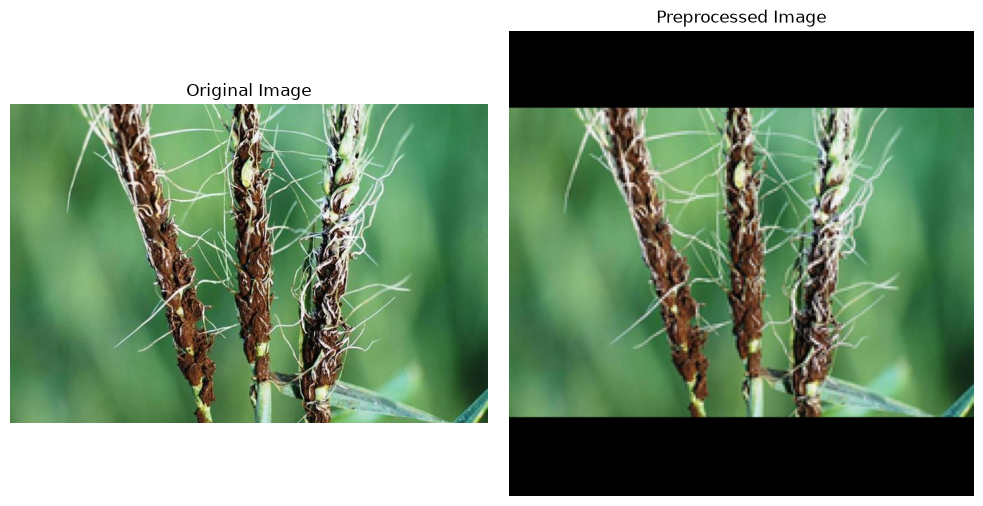

In [7]:
#vizualizing

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(Image.open(image_path))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(processed_image)
axes[1].set_title("Preprocessed Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [8]:
##calculating asect ratios for every image

df_clean["aspect_ratio"] = (
    df_clean["Resolution"]
    .str.split("x")
    .apply(lambda x: float(x[0]) / float(x[1]))
)

print("Minimum aspect ratio:", df_clean["aspect_ratio"].min())
print("Maximum aspect ratio:", df_clean["aspect_ratio"].max())

Minimum aspect ratio: 0.3381843381843382
Maximum aspect ratio: 4.5


In [9]:
# Select images with the smallest and largest aspect ratios

extreme_samples = pd.concat([
    df_clean.nsmallest(3, "aspect_ratio"),
    df_clean.nlargest(3, "aspect_ratio")
])

display(
    extreme_samples[
        ["Name", "Plant", "Disease", "Resolution", "aspect_ratio"]
    ]
)

,Name,Plant,Disease,Resolution,aspect_ratio
184,wheat_head_scab_Bing_0165.jpg,Wheat,wheat head scab,488x1443,0.338184
319,wheat_head_scab_Google_0082.jpg,Wheat,wheat head scab,442x1102,0.401089
315,garlic_rust_103.jpg,Garlic,garlic rust,159x370,0.429730
3079,banana_bunchy_top_Google_0109.jpg,Banana,banana bunchy top,3600x800,4.500000
5695,corn_rust_google_0071.jpg,Corn,corn rust,1440x320,4.500000
3649,blueberry_anthracnose_Bing_0145.jpg,Blueberry,blueberry anthracnose,500x114,4.385965


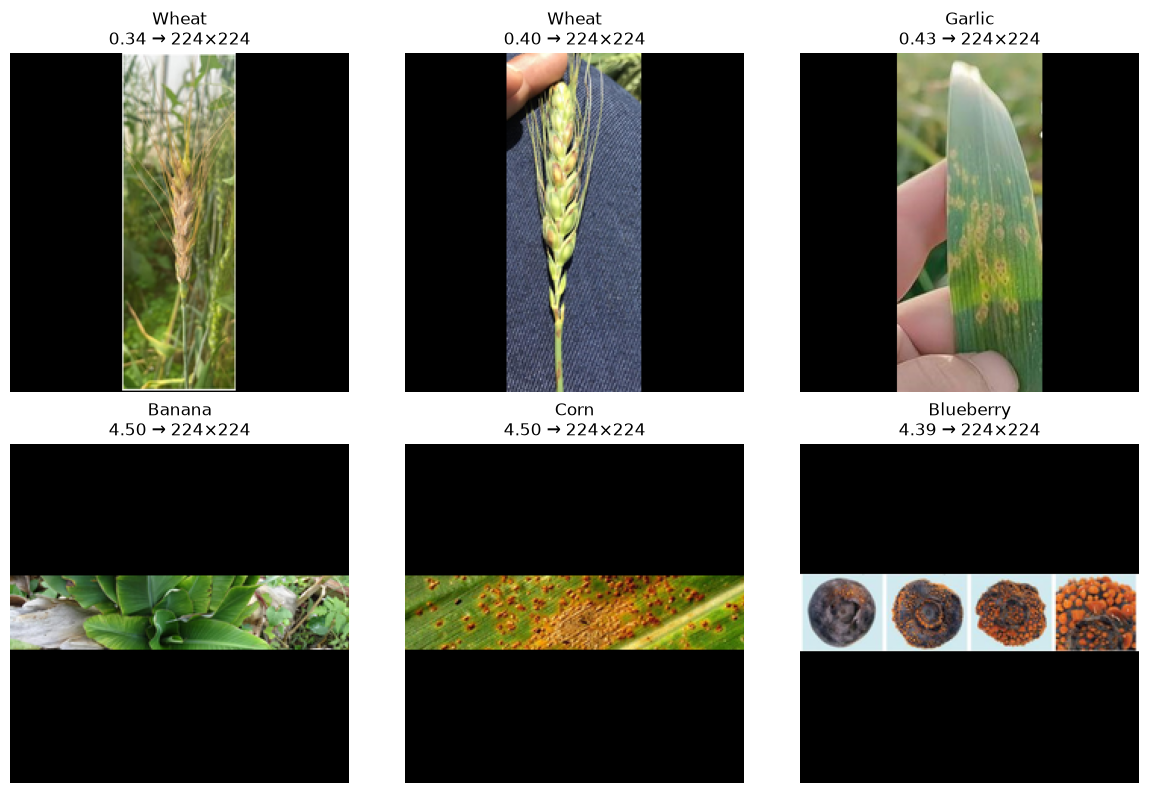

In [10]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 8)
)

for ax, (_, row) in zip(axes.flat, extreme_samples.iterrows()):

    image_path = (
        project_root
        / "data"
        / "raw"
        / "PlantSeg"
        / "images"
        / split_folder[row["Split"]]
        / row["Name"]
    )

    processed = preprocess_image(image_path)

    ax.imshow(processed)
    ax.set_title(
        f'{row["Plant"]}\n'
        f'{row["aspect_ratio"]:.2f} → 224×224'
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# Check disease labels

disease_classes = sorted(df_clean["Disease"].unique())

print("Number of disease classes:", len(disease_classes))

print("\nFirst 20 classes:")
for i, disease in enumerate(disease_classes[:20]):
    print(i, "→", disease)

Number of disease classes: 115

First 20 classes:
0 → apple black rot
1 → apple mosaic virus
2 → apple rust
3 → apple scab
4 → banana anthracnose
5 → banana black leaf streak
6 → banana bunchy top
7 → banana cigar end rot
8 → banana cordana leaf spot
9 → banana panama disease
10 → basil downy mildew
11 → bean halo blight
12 → bean mosaic virus
13 → bean rust
14 → bell pepper bacterial spot
15 → bell pepper blossom end rot
16 → bell pepper frogeye leaf spot
17 → bell pepper powdery mildew
18 → blueberry anthracnose
19 → blueberry botrytis blight


In [12]:
# Create a mapping between disease names and numerical class IDs

disease_to_id = {
    disease: idx
    for idx, disease in enumerate(disease_classes)
}

id_to_disease = {
    idx: disease
    for disease, idx in disease_to_id.items()
}

print("Example mapping:")
for i in range(10):
    print(i, "→", id_to_disease[i])

Example mapping:
0 → apple black rot
1 → apple mosaic virus
2 → apple rust
3 → apple scab
4 → banana anthracnose
5 → banana black leaf streak
6 → banana bunchy top
7 → banana cigar end rot
8 → banana cordana leaf spot
9 → banana panama disease


In [13]:
#adding disease ids

df_clean["disease_id"] = df_clean["Disease"].map(disease_to_id)

print(df_clean[["Disease" , "disease_id"]].head())

                Disease  disease_id
0      wheat loose smut         106
1  wheat powdery mildew         107
2      tomato leaf mold          99
3   tomato early blight          97
4  wheat powdery mildew         107


In [14]:
#verifying the mapping

print("Missing Ids",df_clean["disease_id"].isna().sum())

print("Number of unique ids : ", df_clean["disease_id"].nunique())

print("Number of diseased classes",len(disease_classes))

Missing Ids 0
Number of unique ids :  115
Number of diseased classes 115


In [15]:
#lets check the class distribution

class_distribution = (
    df_clean["disease_id"]
    .value_counts()
    .sort_index()
)

print(class_distribution.head(20))

disease_id
0      62
1      73
2      96
3     166
4      48
5     108
6      72
7      31
8      28
9      49
10     41
11     34
12     33
13     74
14     47
15     78
16     17
17     18
18     26
19     19
Name: count, dtype: int64


In [16]:
print("Smallest class size:", class_distribution.min())
print("Largest class size:", class_distribution.max())
print("Number of classes:", len(class_distribution))

Smallest class size: 3
Largest class size: 321
Number of classes: 115


In [17]:
#checking the splits after adding the labels
print(
    df_clean.groupby(["Split", "disease_id"])
    .size()
    .head(20)
)

Split  disease_id
Test   0             12
       1             13
       2             22
       3             35
       4              9
       5             24
       6             13
       7              9
       8              8
       9             10
       10            10
       11             6
       12             9
       13            14
       14            10
       15            16
       16             4
       17             4
       18             4
       19             3
dtype: int64


In [18]:
#Verifyng that no image content exists in multiple splits

hash_split_counts = (
    df_clean
    .groupby("image_hash")["Split"]
    .nunique()
)

print(
    "Images appearing in multiple splits:",
    (hash_split_counts > 1).sum()
)

Images appearing in multiple splits: 0


In [19]:
#check that every disease class exists in the cleaned dataset

print(df_clean.groupby("disease_id")["Name"].count().describe())

count    115.000000
mean      64.339130
std       51.623959
min        3.000000
25%       28.000000
50%       50.000000
75%       86.000000
max      321.000000
Name: Name, dtype: float64


In [20]:
#creating the masked image

def apply_plant_mask(image,mask):
    """we will keep pixels belonging to the plant region and supress the background""" 

    # Convert both to NumPy arrays
    image_array = np.array(image)
    mask_array = np.array(mask)

    #create a boolean mask from non-zero pixels
    plant_region = mask_array > 0

    #create a black background
    masked_image = np.zeros_like(image_array)

    # keep only plant-region pixels
    masked_image[plant_region] = image_array[plant_region]

    return Image.fromarray(masked_image)

In [21]:
#Lets test

sample = df_clean.iloc[0]

image_path = (
    project_root
    / "data"
    / "raw"
    / "PlantSeg"
    / "images"
    / split_folder[sample["Split"]]
    / sample["Name"]
)

mask_matches = list(
    project_root.glob(
        f"data/raw/PlantSeg/annotations/**/{sample['Label file']}"
    )
)

mask_path = mask_matches[0]

image = Image.open(image_path).convert("RGB")
mask = Image.open(mask_path).convert("L")

masked_image = apply_plant_mask(image, mask)

print("Image:", image.size)
print("Mask:", mask.size)
print("Masked image:", masked_image.size)

Image: (768, 512)
Mask: (768, 512)
Masked image: (768, 512)


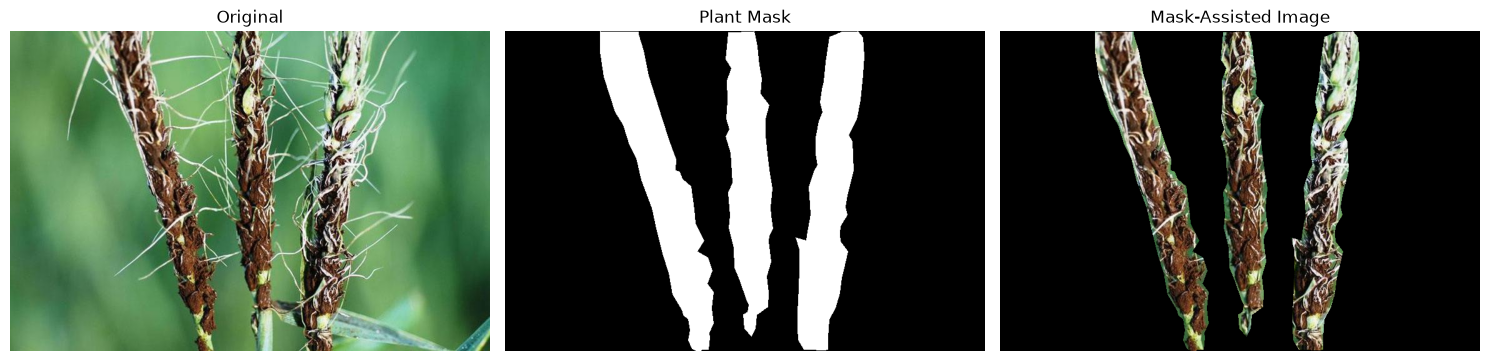

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Plant Mask")
axes[1].axis("off")

axes[2].imshow(masked_image)
axes[2].set_title("Mask-Assisted Image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [23]:
#testing normal vs tiny mask

#select one image with a normal mask ratio
normal_sample = (
    df_clean.iloc[
        (df_clean["Mask ratio"] - 0.20).abs().argsort()[:1]
    ]
    .iloc[0]
)

#select one image with an extremely small mask ratio
tiny_sample = df_clean.loc[
    df_clean["Mask ratio"].idxmin()
]


def get_image_and_mask(row):
    image_path = (
        project_root
        / "data"
        / "raw"
        / "PlantSeg"
        / "images"
        / split_folder[row["Split"]]
        / row["Name"]
    )

    mask_matches = list(
        project_root.glob(
            f"data/raw/PlantSeg/annotations/**/{row['Label file']}"
        )
    )

    mask_path = mask_matches[0]

    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    masked_image = apply_plant_mask(image, mask)

    return image, mask, masked_image


normal_image, normal_mask, normal_masked = get_image_and_mask(
    normal_sample
)

tiny_image, tiny_mask, tiny_masked = get_image_and_mask(
    tiny_sample
)

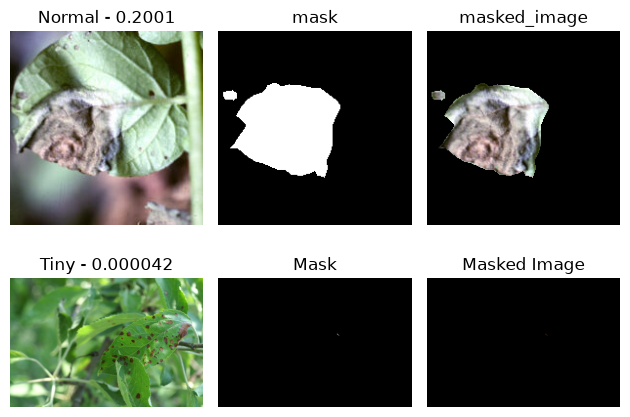

In [24]:
#Displaying them

fig, axes = plt.subplots(2,3)

#normal mask example
axes[0, 0].imshow(normal_image)
axes[0, 0].set_title(f"Normal - {normal_sample['Mask ratio']:.4f}")
axes[0, 0].axis("off")

axes[0,1].imshow(normal_mask,cmap="gray")
axes[0,1].set_title("mask")
axes[0,1].axis("off")

axes[0,2].imshow(normal_masked)
axes[0,2].set_title("masked_image")
axes[0,2].axis("off")

#tiny mask example
axes[1,0].imshow(tiny_image)
axes[1,0].set_title(f"Tiny - {tiny_sample['Mask ratio']:.6f}")
axes[1,0].axis("off")

axes[1, 1].imshow(tiny_mask, cmap="gray")
axes[1, 1].set_title("Mask")
axes[1, 1].axis("off")

axes[1, 2].imshow(tiny_masked)
axes[1, 2].set_title("Masked Image")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

In [25]:
#creating a disease-region overlay

def create_mask_overlay(image,mask):
    #Overlay the annotated disease region on the original image

    image_array = np.array(image).copy()
    mask_array = np.array(mask)

    #identify annoted disease pixels
    disease_region = mask_array > 0

    #creating an overlay image
    overlay = image_array.copy()

    #highlighting the disesed region
    overlay[disease_region] = (0.5 * overlay[disease_region] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)

    return Image.fromarray(overlay)

In [26]:
#testing overlay on our examples
normal_overlay = create_mask_overlay(
    normal_image,
    normal_mask
)

tiny_overlay = create_mask_overlay(
    tiny_image,
    tiny_mask
)

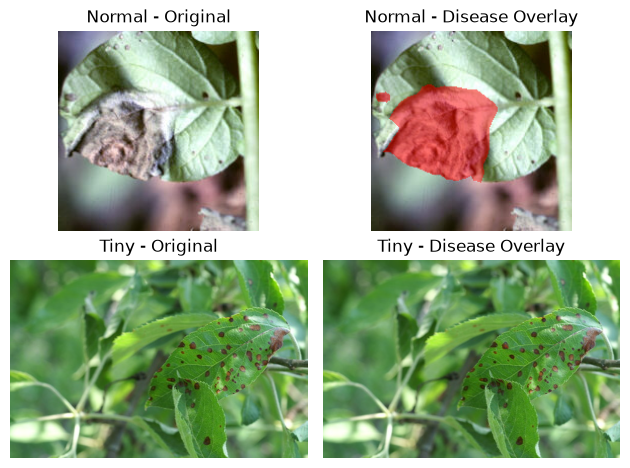

In [27]:
fig, axes = plt.subplots(2, 2)

axes[0, 0].imshow(normal_image)
axes[0, 0].set_title("Normal - Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(normal_overlay)
axes[0, 1].set_title("Normal - Disease Overlay")
axes[0, 1].axis("off")

axes[1, 0].imshow(tiny_image)
axes[1, 0].set_title("Tiny - Original")
axes[1, 0].axis("off")

axes[1, 1].imshow(tiny_overlay)
axes[1, 1].set_title("Tiny - Disease Overlay")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


## Segmentation Mask Interpretation

PlantSeg provides pixel-level masks corresponding to annotated diseased
areas rather than whole-plant or whole-leaf segmentation.

Visual inspection showed that masks can cover large visible disease
regions as well as extremely small regions.

Therefore, the masks will not be used to simply remove the image
background for classification.

Instead, they will be retained for:
- disease-region localization,
- segmentation model training,
- annotated disease-area analysis using mask ratio,
- and later explainability/severity-related analysis.

Images with very small mask ratios are retained because a small
annotated disease region does not necessarily indicate an invalid image.

In [28]:
def image_to_array(image):
    #converting a PIL image to a normalised NumPy array

    image_array = np.array(image).astype(np.float32) / 255.0
    return image_array

In [29]:
#lets verify

processed_image = preprocess_image(image_path)

image_array = image_to_array(processed_image)

print("Shape:", image_array.shape)
print("Minimum:", image_array.min())
print("Maximum:", image_array.max())
print("Data type:", image_array.dtype)

Shape: (224, 224, 3)
Minimum: 0.0
Maximum: 1.0
Data type: float32


PYTORCH IMPORTS

In [30]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.14.0+cpu
CUDA available: False


In [43]:
class ResizeWithPadding:
    def __init__(self, size=(224, 224)):
        self.size = size

    def __call__(self, image):
        target_width, target_height = self.size

        scale = min(
            target_width / image.width,
            target_height / image.height
        )

        new_width = int(image.width * scale)
        new_height = int(image.height * scale)

        image = image.resize(
            (new_width, new_height),
            Image.Resampling.LANCZOS
        )

        canvas = Image.new(
            "RGB",
            self.size,
            (0, 0, 0)
        )

        left = (target_width - new_width) // 2
        top = (target_height - new_height) // 2

        canvas.paste(image, (left, top))

        return canvas

In [44]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    ResizeWithPadding((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

val_test_transform = transforms.Compose([
    ResizeWithPadding((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

In [45]:
#test it on an image

tensor_image = train_transform(processed_image)

print("Tensor shape:", tensor_image.shape)
print("Data type:", tensor_image.dtype)
print("Minimum:", tensor_image.min().item())
print("Maximum:", tensor_image.max().item())

Tensor shape: torch.Size([3, 224, 224])
Data type: torch.float32
Minimum: -2.1179039478302
Maximum: 2.640000104904175


In [73]:
#Building AgrisenseDataset

class AgriSenseDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = Path(row["actual_image_path"])

        image = Image.open(image_path).convert("RGB")
        label = int(row["disease_id"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [74]:
train_df = df_clean[df_clean["Split"] == "Training"].copy()
val_df = df_clean[df_clean["Split"] == "Validation"].copy()
test_df = df_clean[df_clean["Split"] == "Test"].copy()

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Training: 5084
Validation: 811
Test: 1504


In [85]:
#create the dataset object

train_dataset = AgriSenseDataset(
    train_df,
    transform=train_transform
)

val_dataset = AgriSenseDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = AgriSenseDataset(
    test_df,
    transform=val_test_transform
)

In [86]:
#testing one training sample

image_tensor, label = train_dataset[0]

print("Image tensor shape:", image_tensor.shape)
print("Image tensor dtype:", image_tensor.dtype)
print("Disease ID:", label)
print("Disease:", id_to_disease[label])

Image tensor shape: torch.Size([3, 224, 224])
Image tensor dtype: torch.float32
Disease ID: 106
Disease: wheat loose smut


## Create DataLoaders

In [87]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [88]:
#inspecting 1 batch

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)
print("First 10 labels:", labels[:10].tolist())

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image data type: torch.float32
Label data type: torch.int64
First 10 labels: [39, 76, 69, 88, 83, 82, 110, 98, 43, 98]


In [89]:
print("Minimum label in batch:", labels.min().item())
print("Maximum label in batch:", labels.max().item())
print("Number of unique labels:", labels.unique().numel())

Minimum label in batch: 2
Maximum label in batch: 113
Number of unique labels: 29


In [90]:
train_class_counts = train_df["disease_id"].value_counts().sort_index()

print("Number of classes:", train_class_counts.size)
print("Minimum class count:", train_class_counts.min())
print("Maximum class count:", train_class_counts.max())
print("Mean class count:", train_class_counts.mean())
print("Median class count:", train_class_counts.median())

Number of classes: 115
Minimum class count: 2
Maximum class count: 223
Mean class count: 44.208695652173915
Median class count: 35.0


In [91]:
#smallest classes
smallest_classes = train_class_counts.sort_values().head()

for disease_id, count in smallest_classes.items():
    print(f"{disease_id}: {id_to_disease[disease_id]} → {count}")

#largest classes
largest_classes = train_class_counts.sort_values(ascending=False).head()

for disease_id, count in largest_classes.items():
    print(f"{disease_id}: {id_to_disease[disease_id]} → {count}")

41: coffee black rot → 2
68: peach rust → 4
25: broccoli ring spot → 5
65: peach anthracnose → 6
70: plum bacterial spot → 6
38: citrus canker → 223
110: wheat stripe rust → 145
59: grape downy mildew → 145
104: wheat head scab → 133
107: wheat powdery mildew → 116


In [104]:
#validate all splits

for name, loader in [
    ("Training", train_loader),
    ("Validation", val_loader),
    ("Test", test_loader)
]:
    images, labels = next(iter(loader))

    print(f"\n{name}")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)
    print("Has NaN:", torch.isnan(images).any().item())
    print("Has Inf:", torch.isinf(images).any().item())


Training
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64
Has NaN: False
Has Inf: False

Validation
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64
Has NaN: False
Has Inf: False

Test
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64
Has NaN: False
Has Inf: False


### now we have

7,399 cleaned records
62 metadata/filesystem split inconsistencies
metadata split retained as modeling split
actual paths used for file loading
no duplicate hashes among those 62 records

In [105]:
sample_image, sample_label = train_dataset[0]

sample_image_2, sample_label_2 = train_dataset[0]

print("First tensor shape:", sample_image.shape)
print("Second tensor shape:", sample_image_2.shape)
print("Same label:", sample_label == sample_label_2)
print("Images identical:", torch.equal(sample_image, sample_image_2))

First tensor shape: torch.Size([3, 224, 224])
Second tensor shape: torch.Size([3, 224, 224])
Same label: True
Images identical: False


In [106]:
target_name = "banana_cigar_end_rot_Google_0010.jpg"

matches = list(
    (project_root / "data" / "raw" / "PlantSeg").rglob(target_name)
)

print("Matches found:", len(matches))

for path in matches:
    print(path)

Matches found: 1
c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\images\train\banana_cigar_end_rot_Google_0010.jpg


In [107]:
problem_rows = df_clean[
    df_clean["Name"] == target_name
]

problem_rows[
    ["Name", "Plant", "Disease", "Split", "Resolution", "Label file"]
]

,Name,Plant,Disease,Split,Resolution,Label file
57,banana_cigar_end_rot_Google_0010.jpg,Banana,banana cigar end rot,Test,1024x768,banana_cigar_end_rot_Google_0010.png


In [108]:
def find_actual_image_path(row):
    image_root = project_root / "data" / "raw" / "PlantSeg" / "images"

    expected_path = (
        image_root
        / split_folder[row["Split"]]
        / row["Name"]
    )

    if expected_path.exists():
        return expected_path

    matches = list(image_root.rglob(row["Name"]))

    if len(matches) == 1:
        return matches[0]

    return None

In [109]:
df_clean["actual_image_path"] = df_clean.apply(
    find_actual_image_path,
    axis=1
)

print(
    "Images successfully located:",
    df_clean["actual_image_path"].notna().sum()
)

print(
    "Images not located:",
    df_clean["actual_image_path"].isna().sum()
)

Images successfully located: 7399
Images not located: 0


In [110]:
def get_folder_split(path):
    if path is None:
        return None

    for split_name, folder_name in split_folder.items():
        if folder_name in path.parts:
            return split_name

    return None


df_clean["actual_split"] = df_clean["actual_image_path"].apply(
    get_folder_split
)

split_mismatch = df_clean[
    df_clean["Split"] != df_clean["actual_split"]
].copy()

print("Split mismatches:", len(split_mismatch))

Split mismatches: 62


In [111]:
split_mismatch[
    ["Name", "Split", "actual_split", "Plant", "Disease"]
].head(20)

,Name,Split,actual_split,Plant,Disease
57,banana_cigar_end_rot_Google_0010.jpg,Test,Training,Banana,banana cigar end rot
81,cabbage_black_rot_Bing_0013.jpg,Test,Training,Cabbage,cabbage black rot
911,peach_scab_Bing_0253.jpg,Test,Training,Peach,peach scab
973,coffee_brown_eye_spot_Google_0034.jpg,Test,Training,Coffee,coffee brown eye spot
1066,wheat_septoria_blotch_Google_0338.jpg,Validation,Training,Wheat,wheat septoria blotch
1088,wheat_stripe_rust_Bing_0031.jpg,Test,Training,Wheat,wheat stripe rust
1187,wheat_septoria_blotch_google_septoria (13).jpg,Test,Training,Wheat,wheat septoria blotch
1290,grape_downy_mildew_122.jpg,Test,Training,Grape,grape downy mildew
1565,soybean_frog_eye_leaf_spot_Bing_0039.jpg,Test,Training,Soybean,soybean frog eye leaf spot
1645,raspberry_yellow_rust_Google_0013.jpg,Test,Training,Raspberry,raspberry yellow rust


In [112]:
#lets see the mismatch pattern
pd.crosstab(
    split_mismatch["Split"],
    split_mismatch["actual_split"]
)

actual_split,Training,Validation
Split,,
Test,46,7
Validation,9,0


In [113]:
split_mismatch.groupby(
    ["Split", "actual_split"]
).size().sort_values(ascending=False)

Split       actual_split
Test        Training        46
Validation  Training         9
Test        Validation       7
dtype: int64

In [114]:
print(
    "Mismatched images with duplicate hashes:",
    split_mismatch["image_hash"].duplicated(keep=False).sum()
)

Mismatched images with duplicate hashes: 0


In [115]:
print(
    "Unique mismatched image hashes:",
    split_mismatch["image_hash"].nunique()
)

Unique mismatched image hashes: 62


In [71]:
#lets compare annotation folder too

def find_actual_mask_path(row):
    annotation_root = (
        project_root
        / "data"
        / "raw"
        / "PlantSeg"
        / "annotations"
    )

    matches = list(annotation_root.rglob(row["Label file"]))

    if len(matches) == 1:
        return matches[0]

    return None


df_clean["actual_mask_path"] = df_clean.apply(find_actual_mask_path, axis=1)

print(
    "Masks successfully located:",
    df_clean["actual_mask_path"].notna().sum()
)

print(
    "Masks not located:",
    df_clean["actual_mask_path"].isna().sum()
)

Masks successfully located: 7399
Masks not located: 0


In [116]:
def get_annotation_split(path):
    if path is None:
        return None

    for split_name, folder_name in split_folder.items():
        if folder_name in path.parts:
            return split_name

    return None


df_clean["annotation_split"] = df_clean["actual_mask_path"].apply(
    get_annotation_split
)

annotation_mismatch = df_clean[
    df_clean["Split"] != df_clean["annotation_split"]
].copy()

print(
    "Metadata vs annotation split mismatches:",
    len(annotation_mismatch)
)

pd.crosstab(
    df_clean["Split"],
    df_clean["annotation_split"]
)

Metadata vs annotation split mismatches: 62


annotation_split,Test,Training,Validation
Split,,,
Test,1451,46,7
Training,0,5084,0
Validation,0,9,802


In [117]:
#final sanity check 

print("=== AgriSense Preprocessing Checkpoint ===")

print("Total records:", len(df_clean))
print("Unique image contents:", df_clean["image_hash"].nunique())
print("Disease classes:", df_clean["disease_id"].nunique())

print("\nSplit counts:")
print(df_clean["Split"].value_counts())

print("\nMissing values:")
print(df_clean.isna().sum().sum())

print("\nDuplicate image hashes:")
print(df_clean["image_hash"].duplicated().sum())

print("\nSplit mismatches documented:")
print(
    (df_clean["Split"] != df_clean["actual_split"]).sum()
)

print("\nSample tensor shapes:")

for name, loader in [
    ("Training", train_loader),
    ("Validation", val_loader),
    ("Test", test_loader)
]:
    images, labels = next(iter(loader))
    print(f"{name}: {tuple(images.shape)}")

=== AgriSense Preprocessing Checkpoint ===
Total records: 7399
Unique image contents: 7399
Disease classes: 115

Split counts:
Split
Training      5084
Test          1504
Validation     811
Name: count, dtype: int64

Missing values:
0

Duplicate image hashes:
0

Split mismatches documented:
62

Sample tensor shapes:
Training: (32, 3, 224, 224)
Validation: (32, 3, 224, 224)
Test: (32, 3, 224, 224)
